In [1]:
# Loading

import json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from tqdm import tqdm
from pathlib import Path
import warnings
import copy
import csv
import pandas as pd

from sklearn.exceptions import UndefinedMetricWarning
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

np.random.seed(42)
torch.manual_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"

# Paths
ROOT = Path("Amazon_products")
TRAIN_CORPUS_PATH = ROOT / "train" / "train_corpus.txt"
TEST_CORPUS_PATH  = ROOT / "test" / "test_corpus.txt"
CLASS_PATH = ROOT / "classes.txt"

EMB_DIR = Path("SilverGeneration/EmbeddingsRemake")
X_ALL_PATH = EMB_DIR / "X_train_test_mpnet.pt" # Train + Test embeddings
LABEL_EMB_PATH = EMB_DIR / "labels_base_mpnet.pt" # test base also

MODEL_SAVE = Path("Models")
MODEL_SAVE.mkdir(exist_ok=True)
MODEL_PATH = MODEL_SAVE / "Linear.pt"

# Load useful data (like silver gen)
def load_classic(path):
    id2text = {}
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            pid, text = line.strip().split("\t", 1)
            id2text[int(pid)] = text
    return id2text

id2text_train = load_classic(TRAIN_CORPUS_PATH)
id2text_test  = load_classic(TEST_CORPUS_PATH)
train_ids = list(id2text_train.keys())
test_ids  = list(id2text_test.keys())
print(test_ids)
n_train = len(train_ids)
n_test  = len(test_ids)
test_ids  = [n_train + i for i in range(n_test)]
print(test_ids)
print(f"Train IDs: {n_train} | Test IDs: {n_test}")

all_ids = train_ids + test_ids
print(len(set(all_ids)))

# Load X_all + split into X_train & X_test
data = torch.load(X_ALL_PATH, weights_only=False)

# ensure tensor (check)
if isinstance(data, np.ndarray):
    data = torch.from_numpy(data)
elif isinstance(data, list):
    data = torch.stack(data)

X_all = data.float().to(device)

"""X_noisy = X_all + 0.2 * torch.randn_like(X_all)
X_noisy = F.normalize(X_noisy, dim=1)
X_all = X_noisy"""

# Load Class names
classes = {}
with open(CLASS_PATH, "r", encoding="utf-8") as f:
    for line in f:
        cid, cname = line.strip().split("\t")
        classes[int(cid)] = cname

n_classes = len(classes) # 531
print(n_classes)

pid2idx = {pid: i for i, pid in enumerate(all_ids)}


[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221,

In [2]:
class MultiLabelDataset(Dataset):
    """ PyTorch multi-label dataset with fixed document embeddings and hard labels."""
    def __init__(self, pids, labels_dict, scores_dict, n_classes):
        self.pids = pids
        self.labels_dict = labels_dict
        self.scores_dict = scores_dict
        self.n_classes = n_classes

    def __len__(self):
        return len(self.pids)

    def __getitem__(self, idx):
        pid = self.pids[idx]
        emb = X_all[pid2idx[pid]]
        y = torch.zeros(self.n_classes)
        labels = self.labels_dict[pid]
        scores = self.scores_dict[pid]

        for c in labels:
            y[c] = 1.0
        # former version
        # for c, s in zip(labels, scores):
        #    y[c] = float(s)

        return {"pid": pid,"X": emb,"y": y}

In [3]:
# with open("SilverGeneration/SilverCombo/unique_silver_all.json", "r", encoding="utf-8") as f:
# Reminder we have only 27k unique examples and not 49k because we did majority voting before
with open("SilverGeneration/SilverCombo/silver_all.json", "r", encoding="utf-8") as f:
    raw = json.load(f)
silver_labels = {int(pid): data["labels"] for pid, data in raw.items()}
silver_scores = {int(pid): data["scores"] for pid, data in raw.items()}

for pid, data in raw.items():
    labels = data["labels"]
    scores = data["scores"]
    
# TRAIN / VAL splits
silver_ids = list(silver_labels.keys())
silver_train, silver_val = train_test_split(silver_ids, test_size=0.2, random_state=42)

print(f"Train: {len(silver_train)} examples")
print(f"Val: {len(silver_val)} examples")

X_train_split = torch.stack([X_all[pid2idx[pid]] for pid in silver_train])
X_val_split = torch.stack([X_all[pid2idx[pid]] for pid in silver_val])

train_dataset = MultiLabelDataset(silver_train, silver_labels, silver_scores, n_classes)
val_dataset = MultiLabelDataset(silver_val, silver_labels, silver_scores, n_classes)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128)

print(len(train_dataset))
print(len(val_dataset))

Train: 22541 examples
Val: 5636 examples
22541
5636


In [4]:
# setup class hierarchy and child and parents map

CLASS_HIER_PATH = ROOT / "class_hierarchy.txt"
parents_map = {i: [] for i in range(n_classes)}
children_map = {i: [] for i in range(n_classes)}

with open(CLASS_HIER_PATH, "r") as f:
    for line in f:
        p, c = map(int, line.strip().split("\t"))
        parents_map[c].append(p)
        children_map[p].append(c)

hier_pairs = []
for child, parents in parents_map.items():
    for p in parents:
        hier_pairs.append((p, child))


parent_idx = torch.tensor([p for p, c in hier_pairs], device=device)
child_idx  = torch.tensor([c for p, c in hier_pairs], device=device)

label_emb = torch.load(LABEL_EMB_PATH).float().to(device)
print("Label embeddings:", label_emb.shape)

ROOT_SET = {0, 3, 10, 23, 40, 169}
def node_depth(node):
    # explicit roots
    if node in ROOT_SET:
        return 0
    if len(parents_map[node]) == 0:
        return 0
    return 1 + max(node_depth(p) for p in parents_map[node])


depths = [node_depth(i) for i in range(n_classes)]

print("Max hierarchy depth:", max(depths))

Label embeddings: torch.Size([531, 768])
Max hierarchy depth: 3


In [5]:
class LinearClassifier(nn.Module):
    """Simple linear classifier for multi-label prediction from fixed input embeddings."""
    def __init__(self, dim, n_classes, dropout=0.3):
        super().__init__()
        #self.ln = nn.LayerNorm(dim)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(dim, n_classes)

    def forward(self, x):
        #x = self.ln(x)
        x = self.dropout(x)
        return self.fc(x)
    
class InnerProductClassifier(nn.Module):
    """
    Dual-encoder classifier that projects document embeddings into the label
    embedding space and predicts labels via scaled inner products.
    """
    def __init__(self, input_dim, label_emb, hidden_dim=512, dropout=0.3, trainable=True, scale=50):
        super().__init__()
        
        self.proj = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, label_emb.size(1))
        )
        
        self.scale = scale

        if trainable:
            self.label_emb = nn.Parameter(label_emb.clone())
        else:
            self.register_buffer("label_emb", label_emb.clone())

    def forward(self, x):
        x_proj = self.proj(x)
        
        # Normalisation
        x_norm = F.normalize(x_proj, dim=1)
        label_norm = F.normalize(self.label_emb, dim=1)

        # Inner product + scaling
        logits = x_norm @ label_norm.T
        logits = logits * self.scale
        
        return logits

In [6]:
class LabelGCN(nn.Module):
    """
    Graph Convolutional Network applied to label embeddings.
    Propagates label representations using a normalized adjacency matrix
    to inject hierarchical or relational structure between labels.
    """
    def __init__(self, emb_dim, num_layers=2, dropout=0.3):
        super().__init__()

        self.emb_dim = emb_dim
        self.num_layers = num_layers
        self.dropout = dropout

        self.W_list = nn.ParameterList()
        for _ in range(num_layers):
            W = nn.Parameter(torch.empty(emb_dim, emb_dim))
            nn.init.xavier_uniform_(W)
            self.W_list.append(W)

    def forward(self, H, A_hat):
        for i, W in enumerate(self.W_list):
            # No skip connection no need (we work with max 2 layers -> max depth 3)
            H = A_hat @ H
            H = H @ W
            if i < self.num_layers - 1:
                H = F.relu(H)
                H = F.dropout(H, p=self.dropout, training=self.training)

        return H


class GCNClassifier(nn.Module):
    """
    Dual-encoder multi-label classifier combining document embeddings
    with graph-propagated label embeddings via a Label GCN.
    """
    def __init__(self, input_dim, label_init_emb, A_hat, num_layers=2, dropout=0.3):
        super().__init__()
        emb_dim = label_init_emb.size(1)

        # dual encoder 
        # linear proj on docs emb
        self.doc_proj = nn.Linear(input_dim, emb_dim, bias=False)
        self.doc_norm = nn.LayerNorm(emb_dim)
        self.doc_dropout = nn.Dropout(dropout)

        # GCN on labels
        self.label_gcn = LabelGCN(emb_dim, num_layers, 0.05)

        # embeddings trainable
        self.label_emb = nn.Parameter(F.normalize(label_init_emb, dim=1))

        self.register_buffer("A_hat", A_hat)
        self.scale = 50.0

    def forward(self, x, return_label_emb=False):
        # we could use preprocessing here (but not necessary the model is already simple -> it will just add noise)
        E = self.label_gcn(self.label_emb, self.A_hat)
        E = F.normalize(E, dim=1)

        if return_label_emb:
            return E

        # documents
        x = self.doc_proj(x)
        x = self.doc_norm(x)
        x = self.doc_dropout(x)
        x = F.normalize(x, dim=1)

        # logits
        logits = (x @ E.T) * self.scale
        return logits

In [7]:
def build_adj_from_hierarchy(class2children, n_classes, w_parent=1.5):
    """
    Build a symmetric label adjacency matrix and its normalized version (A_hat)
    from a parent–child hierarchy.
    """
    A = torch.zeros((n_classes, n_classes), dtype=torch.float32)

    for parent, children in class2children.items():
        for c in children:
            if parent < n_classes and c < n_classes:
                A[parent, c] = w_parent
                A[c, parent] = w_parent

    A += 0.5*torch.eye(n_classes)
    D = A.sum(dim=1)
    D_inv_sqrt = torch.pow(D, -0.5)
    D_inv_sqrt[torch.isinf(D_inv_sqrt)] = 0
    D_mat = torch.diag(D_inv_sqrt)
    A_hat = D_mat @ A @ D_mat

    return A, A_hat


def check_propagation_strength(A_hat, label_emb):
    """
    Measure how strongly label embeddings are affected by graph propagation
    using cosine similarity before and after applying A_hat.
    """
    H = A_hat.to(device) @ label_emb
    sim = torch.nn.functional.cosine_similarity(H, label_emb, dim=1)
    print("Avg similarity between original and propagated labels:", sim.mean().item())
    
A, A_hat = build_adj_from_hierarchy(children_map, 531, 1.0)
check_propagation_strength(A_hat, label_emb)

Avg similarity between original and propagated labels: 0.9076277017593384


In [8]:
from sklearn.metrics import f1_score, ndcg_score

def evaluate_full(model, loader, k=3):
    """Evaluate function : f1sample, f1macro & f1micro"""
    model.eval()
    
    all_scores = []
    all_true = []
    preds_bin = []

    with torch.no_grad():
        for batch in loader:
            X = batch["X"].to(device)
            y = batch["y"].cpu().numpy()

            y_bin = (y > 0).astype(int)

            logits = model(X)
            prob = torch.sigmoid(logits).cpu().numpy()

            all_scores.extend(prob)
            all_true.extend(y_bin)
            
            sorted_idx = np.argsort(-prob, axis=1)
            pred_bin = np.zeros_like(prob, dtype=int)
            for i in range(prob.shape[0]):
                top1 = sorted_idx[i, 0]
                top2 = sorted_idx[i, 1]
                pred_bin[i, top1] = 1
                pred_bin[i, top2] = 1

                # Top-3 conditionnal
                if k >= 3:
                    top3 = sorted_idx[i, 2]
                    p2 = prob[i, top2]
                    p3 = prob[i, top3]

                    if p3 >= 0.7 * p2:
                        pred_bin[i, top3] = 1

            preds_bin.extend(pred_bin)

    all_scores = np.array(all_scores)
    all_true = np.array(all_true)
    preds_bin = np.array(preds_bin)

    f1_samples = f1_score(all_true, preds_bin, average="samples")  
    f1_micro = f1_score(all_true, preds_bin, average="micro")     
    f1_macro = f1_score(all_true, preds_bin, average="macro")  

    return f1_samples, f1_micro, f1_macro


In [9]:
import matplotlib.pyplot as plt

def plot_all_metrics(results_dict):
    """
    results_dict format:
    {
      "F1_samples": {"Linear": [...], "GNN": [...]},
      "F1_micro":   {"Linear": [...], "GNN": [...]},
      "F1_macro":   {"Linear": [...], "GNN": [...]},
      "Hierarchy_cond":     {"Linear": [...], "GNN": [...]}
    }
    """

    metric_names = ["F1_samples", "F1_micro", "F1_macro", "Hierarchy_cond"]

    # Count how many metrics actually exist
    active_metrics = [m for m in metric_names if m in results_dict]
    n_plots = len(active_metrics)

    plt.figure(figsize=(6 * n_plots, 5))

    for i, metric in enumerate(active_metrics):
        plt.subplot(1, n_plots, i + 1)

        for model_name, values in results_dict[metric].items():
            plt.plot(values, marker="o", label=model_name)

        plt.title(metric.replace("_", " "))
        plt.xlabel("Epoch")
        plt.ylabel(metric)
        plt.grid(True)
        plt.legend()

    plt.tight_layout()
    plt.show()


In [10]:
def hierarchical_parent_loss_fast(logits, parent_idx, child_idx, alpha=1.0):
    """
    Enforce hierarchical consistency by penalizing cases where a child label
    receives a higher probability than its parent.
    """
    # LLM request for O(n)
    probs = torch.sigmoid(logits)
    p = probs[:, parent_idx]
    c = probs[:, child_idx]

    violations = (c > p).float()
    penalty = violations * (c - p)

    return alpha * penalty.mean()

def hierarchy_respect_ratio(logits, parents_map):
    """
    Measure how often score(parent) >= score(child)
    """
    probs = torch.sigmoid(logits)
    total = 0
    ok = 0
    for child, parents in parents_map.items():
        for p in parents:
            ok += (probs[:, p] >= probs[:, child]).float().sum().item()
            total += probs.size(0)

    return ok / total

In [11]:
# TODO -> # noisy + 2 diffents sets of silver labels

# Model call
"""model_gnn = GCNClassifier(
    input_dim=X_all.size(1),
    label_init_emb=label_emb,
    A_hat=A_hat,
    num_layers=1, # 2 => oversmoothing
    dropout=0.3
).to(device)
optimizer_gnn = torch.optim.AdamW([{"params": [model_gnn.label_emb],"lr": 5e-5}, {"params": [p for p in model_gnn.parameters()if p.requires_grad and p is not model_gnn.label_emb],"lr": 5e-4}],weight_decay=1e-3)
"""

model_linear = LinearClassifier(
    dim=X_all.size(1),
    n_classes=n_classes,
    dropout=0.3
).to(device)
optimizer_lin = torch.optim.AdamW([{"params": model_linear.parameters(),"lr": 5e-4}], weight_decay=1e-3)

"""model_inner = InnerProductClassifier(
    input_dim=X_all.size(1),
    label_emb=label_emb,
    dropout=0.3
).to(device)
optimizer_inner = torch.optim.AdamW([{"params": [model_inner.label_emb],"lr": 5e-5}, {"params": [p for p in model_inner.parameters()if p.requires_grad and p is not model_inner.label_emb],"lr": 5e-4}],weight_decay=1e-3)

model_linear2 = LinearClassifier(
    dim=X_all.size(1),
    n_classes=n_classes,
    dropout=0.3
).to(device)

model_gnn2 = GCNClassifier(
    input_dim=X_all.size(1),
    label_init_emb=label_emb,
    A_hat=A_hat,
    num_layers=1,
    dropout=0.3
).to(device)"""

'model_inner = InnerProductClassifier(\n    input_dim=X_all.size(1),\n    label_emb=label_emb,\n    dropout=0.3\n).to(device)\noptimizer_inner = torch.optim.AdamW([{"params": [model_inner.label_emb],"lr": 5e-5}, {"params": [p for p in model_inner.parameters()if p.requires_grad and p is not model_inner.label_emb],"lr": 5e-4}],weight_decay=1e-3)\n\nmodel_linear2 = LinearClassifier(\n    dim=X_all.size(1),\n    n_classes=n_classes,\n    dropout=0.3\n).to(device)\n\nmodel_gnn2 = GCNClassifier(\n    input_dim=X_all.size(1),\n    label_init_emb=label_emb,\n    A_hat=A_hat,\n    num_layers=1,\n    dropout=0.3\n).to(device)'

In [ ]:
def train_one_model(model, MODEL_PATH, use_hier, optimizer):
    """Train Model"""
    optimizer = optimizer
    # we use BCE -> multi label case (with pos waight strong -> more negative case than positive, we increase the power of positive one)
    bce = nn.BCEWithLogitsLoss(pos_weight=torch.full((n_classes,), 20.0).to(device))

    # hyperparameters
    epochs = 40
    val_f1s_list = []
    val_f1m_list = []
    val_f1mic_list = []
    val_hier_list = []

    best_f1 = 0
    best_state = None
    patience = 15
    wait = 0
    drop_prob = 0.05

    lamba_hier = 5.0
    lambda_max = 10.0

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0

        # increase the power of lambda_hier with epochs
        lamba_hier = lamba_hier + (lambda_max-lamba_hier)*epoch/epochs

        for batch in tqdm(train_loader, desc=f"Epoch {epoch}/{epochs}"):
            X = batch["X"].to(device)
            y = batch["y"].to(device)

            # mask for regularization
            logits = model(X)
            mask = (torch.rand_like(y) > drop_prob).float()
            y_ld = y * mask

            # bce + hier loss (if we choose true)
            loss = bce(logits, y_ld) * 2
            if use_hier == True:
                loss += hierarchical_parent_loss_fast(logits, parent_idx, child_idx, alpha=0.25) * lamba_hier #0.25 to avoid too much chgmt
            

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)

        model.eval()
        f1s, f1mic, f1mac = evaluate_full(model, val_loader)


        with torch.no_grad():
            batch = next(iter(val_loader))
            X = batch["X"].to(device)
            logits = model(X)
            ratio = hierarchy_respect_ratio(logits, parents_map)
            print(f"HIERARCHY RESPECT RATIO = {ratio:.4f}")

        val_f1mic_list.append(f1mic)
        val_f1m_list.append(f1mac)
        val_hier_list.append(ratio)
        val_f1s_list.append(f1s)


        print(f"[Epoch {epoch}] loss={avg_loss:.4f} | F1mic={f1mic:.4f} | F1s={f1s:.4f} | F1mac={f1mac:.4f}")

        # Early stopping + best model choice based on f1micro
        if f1mic > best_f1:
            best_f1 = f1mic
            best_state = copy.deepcopy(model.state_dict())
            torch.save(best_state, MODEL_PATH)
            print(f"New best model (F1={best_f1:.4f})")
            wait = 0
        else:
            wait += 1
            print(f" No improvement for {wait} epoch(s).")

        if wait >= patience:
            print(f"\nEarly stopping triggered after {epoch} epochs.")
            break
            

    print(f"Best validation F1 = {best_f1:.4f}")

    model.load_state_dict(best_state)
    save_model = copy.deepcopy(model)
    print(torch.sigmoid(logits[0])[:10])

    return val_f1s_list, val_f1mic_list, val_f1m_list, val_hier_list, save_model

# =====================================

MODEL_PATH_LINEAR = "Models/best_linear.pt"
MODEL_PATH_GNN = "Models/best_gnn.pt"


#gnn_results = train_one_model(model_gnn, MODEL_PATH_GNN, use_hier = True, optimizer=optimizer_gnn)
linear_results = train_one_model(model_linear, MODEL_PATH_LINEAR, use_hier = False, optimizer=optimizer_lin)
"""inner_results = train_one_model(model_inner, MODEL_PATH_LINEAR, use_hier = True, optimizer=optimizer_inner)
gnn_results2 = train_one_model(model_gnn2, MODEL_PATH_GNN, use_hier = False)
linear_results2 = train_one_model(model_linear2, MODEL_PATH_LINEAR, use_hier = False)"""


Epoch 1/40: 100%|██████████| 177/177 [00:00<00:00, 247.49it/s]


HIERARCHY RESPECT RATIO = 0.9552
[Epoch 1] loss=1.1897 | F1mic=0.4277 | F1s=0.4291 | F1mac=0.0208
New best model (F1=0.4277)


Epoch 2/40: 100%|██████████| 177/177 [00:00<00:00, 274.12it/s]


HIERARCHY RESPECT RATIO = 0.9753
[Epoch 2] loss=0.7808 | F1mic=0.4609 | F1s=0.4624 | F1mac=0.0290
New best model (F1=0.4609)


Epoch 3/40: 100%|██████████| 177/177 [00:00<00:00, 280.15it/s]


...

Epoch 39/40: 100%|██████████| 177/177 [00:01<00:00, 172.56it/s]


HIERARCHY RESPECT RATIO = 0.9213
[Epoch 39] loss=0.0839 | F1mic=0.7609 | F1s=0.7627 | F1mac=0.2765
New best model (F1=0.7609)


Epoch 40/40: 100%|██████████| 177/177 [00:01<00:00, 160.02it/s]


HIERARCHY RESPECT RATIO = 0.9208
[Epoch 40] loss=0.0825 | F1mic=0.7626 | F1s=0.7644 | F1mac=0.2806
New best model (F1=0.7626)
Best validation F1 = 0.7626
tensor([0.1023, 0.0081, 0.0075, 0.0085, 0.0167, 0.0038, 0.0038, 0.0124, 0.5055,
        0.0061], device='cuda:0')


'inner_results = train_one_model(model_inner, MODEL_PATH_LINEAR, use_hier = True, optimizer=optimizer_inner)\ngnn_results2 = train_one_model(model_gnn2, MODEL_PATH_GNN, use_hier = False)\nlinear_results2 = train_one_model(model_linear2, MODEL_PATH_LINEAR, use_hier = False)'

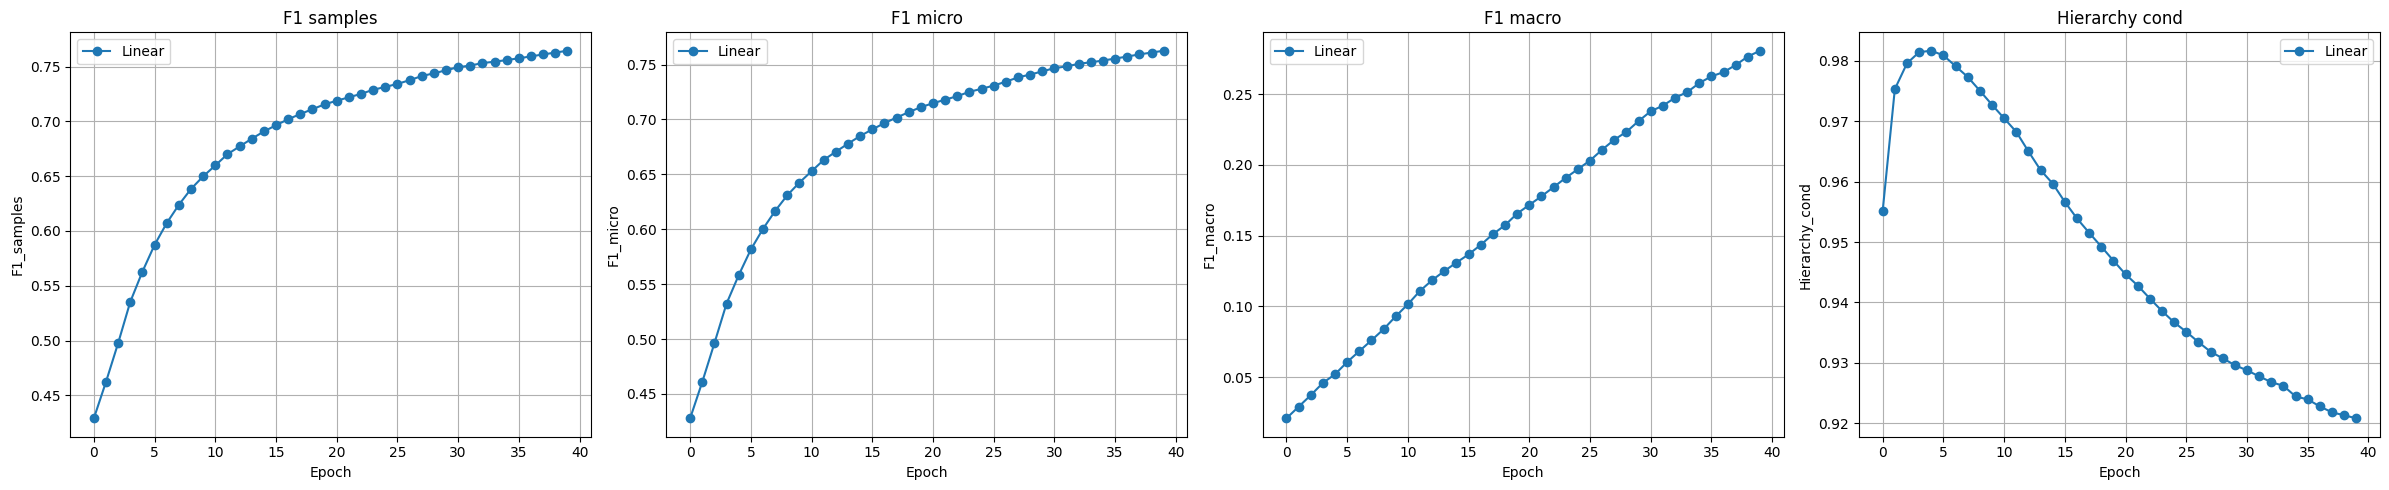

In [13]:
val_f1s_linear, val_f1mic_linear, val_f1m_linear, val_hier_linear, save_model_linear = linear_results
#val_f1s_gnn, val_f1mic_gnn, val_f1m_gnn, val_hier_gnn, save_model_gnn = gnn_results
"""val_f1s_inner, val_f1mic_inner, val_f1m_inner, val_hier_inner, save_model_inner = inner_results

results_dict = {
    "F1_samples":{"Linear": val_f1s_linear, "GNN": val_f1s_gnn, "Inner": val_f1s_inner},
    "F1_micro": {"Linear": val_f1mic_linear, "GNN": val_f1mic_gnn, "Inner": val_f1s_inner},
    "F1_macro": {"Linear": val_f1m_linear, "GNN": val_f1m_gnn, "Inner": val_f1s_inner},
    "Hierarchy_cond": {"Linear": val_hier_linear, "GNN": val_hier_gnn, "Inner": val_f1s_inner},
}


plot_all_metrics(results_dict)
plot_all_metrics(results_dict2)"""

results_dict = {
    "F1_samples":{"Linear": val_f1s_linear},
    "F1_micro": {"Linear": val_f1mic_linear},
    "F1_macro": {"Linear": val_f1m_linear},
    "Hierarchy_cond": {"Linear": val_hier_linear},
}

plot_all_metrics(results_dict)


In [14]:
def select_k(prob, min_k=2, max_k=3):
    """
    Select the top-k labels based on probability with a confidence-based
    """
    idx = np.argsort(prob)[::-1]
    top3 = idx[:max_k]
    if prob[top3[2]] < 0.70 * prob[top3[1]]:
        return top3[:2]
    return top3

def run_submission(model, test_ids, X_all, pid2idx, n_train, out_path):
    """
    Run inference on the test set and generate a submission file with
    predicted labels for each sample.
    """
    model.eval()
    preds = []
    batch_size = 64
    with torch.no_grad():
        for b_start in tqdm(range(0, len(test_ids), batch_size)):
            batch_pids = test_ids[b_start:b_start + batch_size]

            batch_emb = torch.stack([X_all[pid2idx[pid]] for pid in batch_pids]).to(device)

            logits = model(batch_emb)
            probs = torch.sigmoid(logits).cpu().numpy()

            for p in probs:
                labels = select_k(p)
                preds.append([str(x) for x in labels])

    OUT_DIR = Path("Submission")
    OUT_DIR.mkdir(exist_ok=True)

    with open(out_path, "w", newline="", encoding="utf-8") as f:
        w = csv.writer(f)
        w.writerow(["id", "label"])
        for pid, labels in zip(test_ids, preds):
            true_test_id = pid - n_train
            w.writerow([true_test_id, ",".join(labels)])

    print(f"Submission saved -> {out_path}")

run_submission(
    model=save_model_linear,
    test_ids=test_ids,
    X_all=X_all,
    pid2idx=pid2idx,
    n_train=n_train,
    out_path="Submission/submission_linear.csv"
)

"""run_submission(
    model=save_model_gnn,
    test_ids=test_ids,
    X_all=X_all,
    pid2idx=pid2idx,
    n_train=n_train,
    out_path="Submission/submission_gnn.csv"
)

run_submission(
    model=save_model_gnn2,
    test_ids=test_ids,
    X_all=X_all,
    pid2idx=pid2idx,
    n_train=n_train,
    out_path="Submission/submission_gnn2.csv"
)"""


100%|██████████| 308/308 [00:00<00:00, 389.62it/s]


Submission saved -> Submission/submission_linear.csv


'run_submission(\n    model=save_model_gnn,\n    test_ids=test_ids,\n    X_all=X_all,\n    pid2idx=pid2idx,\n    n_train=n_train,\n    out_path="Submission/submission_gnn.csv"\n)\n\nrun_submission(\n    model=save_model_gnn2,\n    test_ids=test_ids,\n    X_all=X_all,\n    pid2idx=pid2idx,\n    n_train=n_train,\n    out_path="Submission/submission_gnn2.csv"\n)'